# Purpose: 
- Preprocess and save the post-RTC image
- Partition the image into multiple segments and save the label as a np.array

In [1]:
import sys
import os
from pathlib import Path

# Add the path to the utils folder to sys.path
utils_path = Path('/hpc/home/a1/WildfireProject/uavsar-fire-detect-main/uavsar-main/python').resolve()
sys.path.append(str(utils_path))

import rasterio
import numpy as np
from pathlib import Path
from process_utils import (preprocess_data,
                           superpixel_segmentation)
from rio_utils import (reproject_arr_to_match_profile)
from edit_path_utils import (edit_paths)

---
## Load the images into arrays

**Parameter**:
- `tifs` (list): a list containing the paths to the images

In [2]:
# Opens a GeoTIFF and loads the backscatter values and profile
def open_one(path):
    with rasterio.open(path) as ds:
        band = ds.read(1)
        profile = ds.profile
    return band, profile

In [3]:
# Path to the folder with the cropped images
data_dir = Path('/hpc/home/a1/FishLakeFireData/WeightedIncMergeFiles')
tifs = sorted(list(data_dir.glob('./*fishlake_hv_*.tif')))
tifs

[PosixPath('/hpc/home/a1/FishLakeFireData/WeightedIncMergeFiles/fishlake_hv_0.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/WeightedIncMergeFiles/fishlake_hv_1.tif')]

---
Open the raster images and preprocess them.

Let `hv_0` and `profile_0` correspond to the pre-fire image, and `hv_1` and `profile_1` correspond to the post-fire image

In [4]:
# Open the tifs
bands, profiles = zip(*map(open_one, tifs))
hv_0 = bands[0]
hv_1 = bands[1]
profile_0 = profiles[0]
profile_1 = profiles[1]

---
## Preprocess the image
Applies interpolation, clipping, total-variation denoising, and background mask

**Parameters**
- `interpolation` (bool): whether or not to perform nearest neighbor interpolation for the preprocessing
- `weight` (float): denoising weight. The greater the weight, the more denoising (at the expense of fidelity to image). 

In [5]:
interpolation = True
weight = 5

In [6]:
hv_0 = preprocess_data(hv_0, interpolation, weight)
hv_1 = preprocess_data(hv_1, interpolation, weight)
print("Preprocessing done")

Preprocessing done


---
Reprojecting the array to match the profile of pre- and post- fire images, so arithmetic could be performed

In [7]:
# reproject the later flight to match the profile of the earlier flight
hv_1, _ = reproject_arr_to_match_profile(hv_1, profile_1, profile_0, resampling='bilinear')
hv_1 = hv_1[0]  # getting back to 2-D
print("Reproject done")

Reproject done


___
Saving the output to avoid long run-time in the future

**Parameters**
- `output_path_0` (str): output path for the processed pre-fire image [**.tif** file]
- `output_path_1` (str): output path for the processed post-fire image [**.tif** file]

In [8]:
output_path_0 = "/hpc/home/a1/FishLakeFireData/Data_Output_HV_Logratio/fishlake_hv_0_preprocessed_interpolated.tif"
output_path_1 = "/hpc/home/a1/FishLakeFireData/Data_Output_HV_Logratio/fishlake_hv_1_preprocessed_interpolated.tif"

In [9]:
with rasterio.open(output_path_0, "w", **profile_0) as dest:
    dest.write(hv_0, 1)
with rasterio.open(output_path_1, "w", **profile_0) as dest:
    dest.write(hv_1, 1)

___ 
## Superpixel Segmentation
Performs superpixel segmentation using [Felzenszwalb's algorithm](https://scikit-image.org/docs/stable/api/skimage.segmentation.html#skimage.segmentation.felzenszwalb) implemented by scikit-image to partition each image into multiple segments. The run time depends on the size of the images (~5-30mins)

**Parameters**
- `min_size` (int): minimum component size for Felzenszwalb's algorithm. Enforced using postprocessing. Check the hyperlink about scikit-learn implementation for more information
- `superpixel_out_path` (str): output path for the superpixel label as np.array. [**.npy**]

In [11]:
scale = 1
sigma = 0
min_size = 1

In [12]:
superpixel_labels = superpixel_segmentation(hv_0,hv_1, scale=scale, sigma=sigma, min_size=min_size)
print("Superpixel done")
print(superpixel_labels)

Superpixel done
[[      0       0       0 ...     818     818     818]
 [      0       0       0 ...     818     818     818]
 [      0       0       0 ...     818     818     818]
 ...
 [1953551 1953551 1953551 ... 1872129 1872129 1872129]
 [1953551 1953551 1953551 ... 1872129 1872129 1872129]
 [1953551 1953551 1953551 ... 1872129 1872129 1872129]]


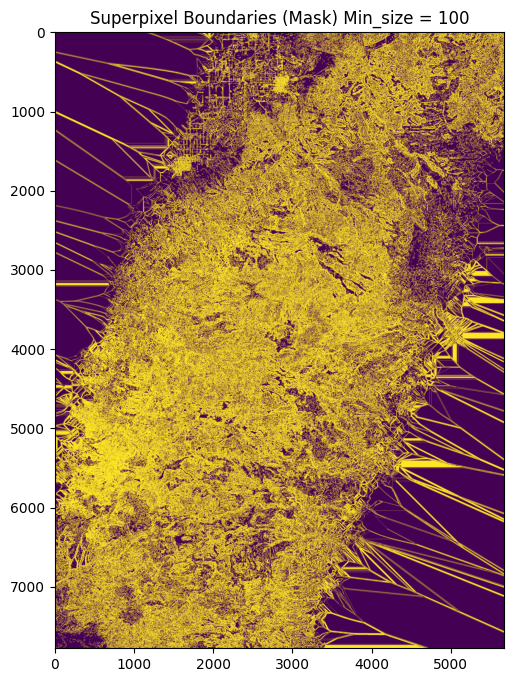

In [13]:
from skimage.segmentation import find_boundaries
import matplotlib.pyplot as plt

# Create a binary boundary map
boundary_mask = find_boundaries(superpixel_labels)

plt.figure(figsize=(8, 8))
plt.imshow(boundary_mask)
plt.title('Superpixel Boundaries (Mask) Min_size = 100')
plt.axis
plt.show()


In [14]:
base_dir = "/hpc/home/a1/FishLakeFireData/SuperPixel_Labels"

superpixel_out_path = os.path.join(
    base_dir,
    f"superpixel_labels_hv_scale{scale}_sigma{str(sigma).replace('.','')}_minsize{min_size}.npy"
)

np.save(superpixel_out_path, superpixel_labels)